---
title: "Dataset of the Week #5: Philadelphia Shooting Reports"
author: Maggie Goldman
date: 3/23/2026
categories:
  - DOW
  - Python
---

# Philadelphia Shooting Reports:

### Who is most at risk for severe gunshot injuries in Philadelphia?

##### Shootings can be really scary and they are sadly more and more prevalent by the day. Philadelphia is a large, urban landscape, and unfortunately the prime target for these attacks. My hopes from approaching this dataset is to educate about the risks of shootings based on gender and age, specifically whether or not college students are targets.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [3]:
shoot_df = pd.read_csv('data/shootings.csv') 

Firstly, we're going to start by diving into the gender of victims.

In [5]:
shoot_df['sex'].value_counts()

sex
M    15608
F     1882
Name: count, dtype: int64

This dataset accounts for over 15,000 men and only 1,800 women, demonstrating how men are higher risk for injury in the Philadelphia area.

Next, we're going to dive into a closer examination of who is most susceptible to specific wound types: Chest, Head, Leg and Arm

In [40]:
shoot_df["injury_clean"] = shoot_df["wound"].str.strip().str.upper()

In [41]:
target_injuries = ["CHEST", "HEAD", "LEG", "ARM"]

filtered_df = shoot_df[shoot_df["injury_clean"].isin(target_injuries)]

In [42]:
gender_injury = pd.crosstab(filtered_df["sex"], filtered_df["injury_clean"])
print(gender_injury)

injury_clean  ARM  CHEST  HEAD   LEG
sex                                 
F             141    101   253   422
M             842    936  1263  2952


In [43]:
gender_injury_pct = pd.crosstab(
    filtered_df["sex"],
    filtered_df["injury_clean"],
    normalize="index"
) * 100

print(gender_injury_pct.round(2))

injury_clean    ARM  CHEST   HEAD    LEG
sex                                     
F             15.38  11.01  27.59  46.02
M             14.05  15.62  21.07  49.26


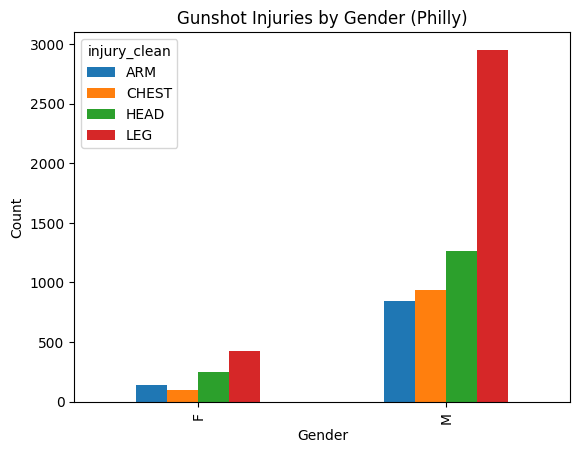

In [20]:
gender_injury.plot(kind="bar")
plt.title("Gunshot Injuries by Gender (Philly)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

As seen visually, a majority of male and female victims get shot in the arm and they are second most likely to get shot in the head. The only differentiation between male and female is the amount of shots towards the arm and chest. Females are least likely to get shot in the chest, whereas men are least likely to get shot in the arm. 

This points to a subtle gender-based variation in injury patterns. These differences, though not immediately obvious in aggregate trends, may reflect variations in context, positioning, or circumstances surrounding incidents of violence. Rather than indicating entirely distinct patterns, they suggest that gender shapes the nature of exposure to violence in more nuanced ways.

Next, we're going to take in account the rate of shootings in college students (From the ages of 18-22). There are a lot of colleges in the Philadelphia region (Penn, Drexel, Temple, etc) and it's important to remain safe and stay educated about specific dangers and who is the most at risk.

In [44]:
age_counts = college_df["age"].value_counts().sort_index()
print(age_counts)

age
18.0    267
19.0    341
20.0    307
21.0    332
22.0    299
Name: count, dtype: int64


In [45]:
age_rate = age_counts / age_counts.sum() * 100
print(age_rate.round(2))

age
18.0    17.27
19.0    22.06
20.0    19.86
21.0    21.47
22.0    19.34
Name: count, dtype: float64


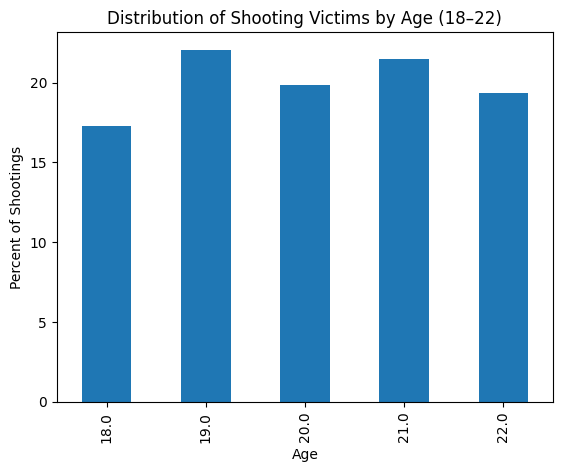

In [46]:
age_rate.plot(kind="bar")

plt.title("Distribution of Shooting Victims by Age (18–22)")
plt.xlabel("Age")
plt.ylabel("Percent of Shootings")
plt.show()

As seen here, 19 year olds are at the highest risk of getting shot, encapsulating 22% of the group. 18 year olds are the least likely to get shot, only taking up around 17%.

Finally, we're going to be examining a combination of everything, diving into the intersection of gender, injury type, and age.

In [26]:
college_df = filtered_df[
    filtered_df["age"].isin([18, 19, 20, 21, 22])
].copy()

In [27]:
college_df["sex"] = college_df["sex"].str.upper().str.strip()
college_df["injury_clean"] = college_df["injury_clean"].str.upper().str.strip()

In [32]:
college_df.groupby(["age", "sex"]).size()

age   sex
18.0  F       29
      M      238
19.0  F       38
      M      303
20.0  F       37
      M      270
21.0  F       38
      M      294
22.0  F       42
      M      257
dtype: int64

In [30]:
counts = pd.crosstab(
    [college_df["age"], college_df["sex"]],
    college_df["injury_clean"]
)

print(counts)

injury_clean  ARM  CHEST  HEAD  LEG
age  sex                           
18.0 F          1      5     6   17
     M         39     31    41  127
19.0 F          4      2     6   26
     M         58     34    57  154
20.0 F          9      1     6   21
     M         42     35    55  138
21.0 F          5      2    12   19
     M         38     53    70  133
22.0 F          6      7    11   18
     M         41     28    54  134


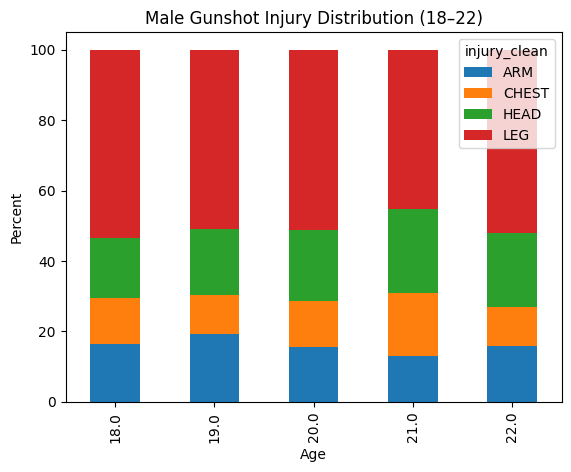

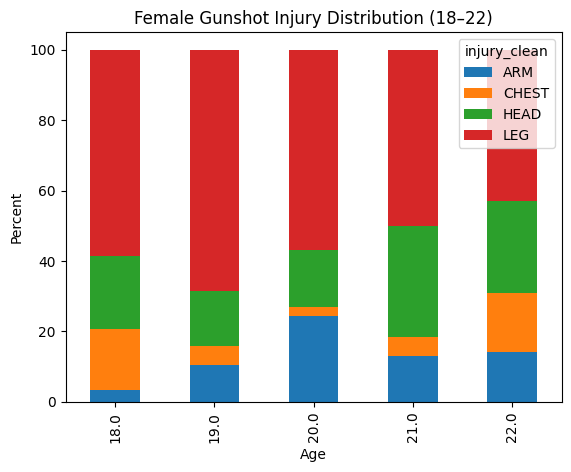

In [33]:
male_data = age_gender_injury.xs("M", level="sex")
female_data = age_gender_injury.xs("F", level="sex")

male_data.plot(kind="bar", stacked=True)
plt.title("Male Gunshot Injury Distribution (18–22)")
plt.xlabel("Age")
plt.ylabel("Percent")
plt.show()

female_data.plot(kind="bar", stacked=True)
plt.title("Female Gunshot Injury Distribution (18–22)")
plt.xlabel("Age")
plt.ylabel("Percent")
plt.show()

In [35]:
age_injury = pd.crosstab(
    college_df["age"],
    college_df["injury_clean"],
    normalize="index"
) * 100

print(age_injury.round(2))

injury_clean    ARM  CHEST   HEAD    LEG
age                                     
18.0          14.98  13.48  17.60  53.93
19.0          18.18  10.56  18.48  52.79
20.0          16.61  11.73  19.87  51.79
21.0          12.95  16.57  24.70  45.78
22.0          15.72  11.71  21.74  50.84


This analysis reveals that gunshot injury patterns among 18–22 year olds in Philadelphia are both highly concentrated and subtly differentiated across gender. Across all ages, extremity injuries—particularly to the leg—consistently make up the largest share of wounds for both males and females, suggesting that many incidents do not immediately result in fatal outcomes. However, head injuries also appear at notably high rates, especially among males, indicating a persistent presence of more severe and potentially life-threatening violence within this age group.

Gender differences, while less pronounced in overall distribution, become more apparent when examining specific injury types. Males experience significantly higher counts across all injury locations, reflecting a disproportionate exposure to gun violence overall. At the same time, females show relatively lower counts and a slightly different distribution, particularly with fewer chest injuries, suggesting differences in the circumstances or contexts in which violence occurs.

Importantly, variation across ages 18 to 22 is relatively consistent rather than sharply fluctuating, indicating that risk remains steady throughout early adulthood rather than peaking at a single age. This challenges the assumption that vulnerability is concentrated at one specific point and instead highlights that exposure to violence is sustained across these formative years.

Ultimately, these findings emphasize the importance of examining both distribution and demographic differences to fully understand how risk operates within this population.